# Week 1 Monday - Letter Frequency

Motivating questions for today.

Consider the following 20 strings.  One of them is *shift ciphertext* (meaning it was obtained from English by removing spaces and shifting each letter by the same amount), and the rest are random.

```
NJYJNYMEDBDDAXBTQGIAVQWWJXTTGRECNAOOQSUMPYDY
UOZGXDGBINYGHTYMBJKDSFOTTNPUZRUSNYPSQHSUMXDI
ILTFAEXYJGCAZNRXVILDVSWYFHAQEOJPKBXFKGODOABL
TNFZBAFREIGGDDPGOZVYOFMDSAWTTGDNSJCXAOCEIWPV
UHJIGWXPOVOVIBHWMEHZLAONHJCTIPECKXVGRTGLITQR
BQLTWBLNVTKLWWSZIKWQOFOJFBZLZSIRKJFAHTDTAJIL
ILKWRUXWLZBIURLUPPNZEOSBCSRLPWAXMHJJCTQKJOOZ
PTODVCQAGMGDGQFLLQEXIPKHMZIRYDYTAKWHBZQAOYTD
QRGBYXWPOITKAOMBANEEZJRMVSSFNMEVSGZFTWCFWACH
DAASYKEBEUWTZBFPKLRXZVLCEWSWUQVIRAPUXCTOMPSL
XPPSFVQKLGKPLQRZIWWKGORUKCGPEVFRPZRTEANTVANF
EKICVABHEMRVSKVMMJLYGWCVULRINLOHLRVUKAVFEBWG
HZIIGDICWMRLVRLWYYSXLTRMLJJTPGUNWBDUCHRWNRYX
AWIVDHPKLDSRAKDNXUTYBVNGEGZRYLGDSDHZJIRDQXSG
OWSBYPPVXBATUBEBSJJEHAWPZUKBBYEUGNLDJJVFVIPM
BPIWDCTHTKTCINIWGTTPHJBBTGHTHHXDCDCTJRXGKXCT
WOTMFMEPCWIZLBVZENBDWUUYJVJRBVLQUCMYTEDUFIEU
XOLSJHRDODYQFLSPFHIHZSNXZYFZMZGJNYFWQEPPFHQK
FUTWLMYHFYLHRMIRJOGBDUNTJDGWLDBWRULWDUDHDHBZ
DLSVRDGWWWZNOTLMJRNSCMPMGHCMTUCVCRNPUFIDFDJG
```

* How can we distinguish the ciphertext from the random strings?
* Once we've identified the ciphertext, how can we recover the original *plaintext*?
* How could we recover the original plaintext automatically?

*Apple*: command-shift-m converts a code cell to a markdown cell

*Windows*: only need to press m

You can also make the conversion by clicking in the menu above.

Please read the lab 0 instructions to create your own Workspace on the Education plan.

## Prerequisite
Please run the following cell before starting. It has built-in functions that will help us. You do not need to know how to write all of these functions, just how to use them.

In [1]:
import string
from collections import Counter

import numpy as np
import pandas as pd
import altair as alt

def only_letters(X, case=None):
    '''Returns the string obtained from X by removing everything but the letters.
    If case="upper" or case="lower", then the letters are all
    converted to the same case.'''
    X = ''.join(c for c in X if c in string.ascii_letters)

    if len(X) == 0:
        return None
    
    if case is None:
        return X
    elif case == "lower":
        return X.lower()
    elif case == "upper":
        return X.upper()


def shift_char(ch, shift_amt):
    '''Shifts a specific character by shift_amt.
    Example:
    shift_char("Y", 3) returns "B"
    '''
    if ch in string.ascii_lowercase:
        base = 'a' 
    elif ch in string.ascii_uppercase:
        base = 'A'
    # It's not clear what shifting should mean in other cases
    # so if the character is not upper or lower-case, we leave it unchanged
    else:
        return ch
    #use ord to get the unicode number for each character
    # ord("a") = 97 and ord("A") = 65
    letter_order25 = ord(ch)-ord(base) #turns unicode values into 0 to 25 alphabet encoding
    shifted_order25 = (letter_order25+shift_amt)%26
    shifted_unicode = shifted_order25 + ord(base) #+ord(base) puts us back to unicode
    return chr(shifted_unicode)


def shift_string(X, shift_amt):
    '''Shifts all characters in X by the same amount.'''
    return ''.join(shift_char(ch, shift_amt) for ch in X)


def get_shift_ciphertext(source, length):
    source = only_letters(source, case="upper")
    rng = np.random.default_rng()
    start = rng.integers(0, len(source) - length + 1)
    plaintext = source[start: start+length]
    shift_amt = rng.integers(1, 26)
    return shift_string(plaintext, shift_amt)


def count_substrings(X,n):
    '''Returns a Python Counter object of all n-grams in X.'''
    if not X:
        return {}
    X = only_letters(X)
    shifts = [X[i:] for i in range(n)]
    grams = [''.join(chrs) for chrs in zip(*shifts)]
    return Counter(grams)


def get_freq(X, case="lower"):
    '''Returns the proportion that each letter occurs in "X"'''
    
    if case == "lower":
        letters = string.ascii_lowercase
    elif case == "upper":
        letters = string.ascii_uppercase
    else:
        raise ValueError("case should be 'upper' or 'lower'.")
    
    X = only_letters(X, case=case)
    n = len(X)
    ctr = count_substrings(X, 1)
    output = {}
    for char in letters:
        output[char] = ctr[char]/n
    return output


def freq_chart(X, case="upper"):
    '''Plot the letter frequency chart.'''
    X = only_letters(X, case=case)
    if case == "lower":
        letters = list(string.ascii_lowercase)
    elif case == "upper":
        letters = list(string.ascii_uppercase)
    else:
        raise ValueError("case should be 'upper' or 'lower'.")

    freq_dict = get_freq(X, case=case)
    ser_count = pd.Series(freq_dict, name="freq")
    df_count = pd.DataFrame(ser_count).reset_index()
    df_count.rename({"index": "letter"}, axis=1, inplace=True)

    chart = alt.Chart(df_count).mark_bar().encode(
        x=alt.X("letter", scale=alt.Scale(domain=letters)),
        y="freq",
        tooltip=["letter", "freq"]
    )

    return chart


def mut_ind_co(d1, d2):
    '''For letter frequency dictionaries d1 and d2, return the Mutual Index of Coincidence.
    See Equation (5.9) on page 222 in Hoffstein, Pipher, Silverman.'''
    s = 0
    for k in d1.keys():
        s += d1.get(k, 0)*d2.get(k,0)
    return s


def ind_co(d):
    '''Return an estimate for the index of coincidence for the letter frequency dictionary d.
    Note: We are computing the probability of drawing the same letter twice "with replacement".
    The precise definition is "without replacement".'''
    return mut_ind_co(d, d)

## English Text and its letter frequency

In [3]:
# Getting a long string of English text
with open("PridePrejudice.txt", "r", encoding="utf-8") as f:
    s = f.read()

In [5]:
type(s)

str

In [7]:
len(s)

748079

To get a good estimate of character frequency in English, We will sample the book _Pride and Prejudice_ by Jane Austen.

In [10]:
freq_chart(s)

C:\ProgramData\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

Compare this chart to the 4th string in our list.

In [12]:
t = "TNFZBAFREIGGDDPGOZVYOFMDSAWTTGDNSJCXAOCEIWPV"

In [16]:
len(t)

44

In [18]:
freq_chart(t)

C:\ProgramData\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

Since string `t` only has 44 characters, it is difficult to tell whether the peaks in our chart are caused by similarity to shifted English text. It could just be due to randomness and variance.

## Random Text and its letter frequency

We will generate some random text below and see how it behaves.

In [20]:
import numpy as np
import string

In [22]:
rng = np.random.default_rng() #create a Random Number Generator object

In [24]:
string.ascii_uppercase #one string with all capitals

'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

In [26]:
list(string.ascii_uppercase) #must convert this string to a list to use it with rng.

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z']

In [28]:
temp = rng.choice(list(string.ascii_uppercase), size=750000) #Sample 750,000 letters from the list above, with replacement
temp[:10] #Print the letters in the first 10 indices, 0 through 9

array(['P', 'S', 'U', 'K', 'T', 'Z', 'Y', 'B', 'H', 'M'], dtype='<U1')

In [30]:
temp = rng.choice(list(string.ascii_uppercase), size=750000) #running this line again rerandomizes the list
t2 = ''.join(temp) #Turn the small list into a string
t2[:10]

'QFKWNEURPS'

Below is a relative frequency histogram of our sample of 750,000 characters. Note that the percentages are all roughly the same, i.e. the variance of this sample is very low.

In [33]:
freq_chart(t2)

C:\ProgramData\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

In [35]:
1/26

0.038461538461538464

Now let's look at a frequency chart of just the first 44 characters.

In [38]:
freq_chart(t2[:44])

C:\ProgramData\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

A small sample has an high chance that some characters are represented much more frequently than others. So these peaks are not enough to determine whether the text is truely random or whether the text is shifted English.

## Generate charts for each string

In [42]:
# Getting a list of the 20 strings from above
f = open("strings20.txt", "r")
lines = f.readlines()

In [44]:
len(lines)

20

In [46]:
lines[3] #4th line is at index 3. Remember that the first line is at index 0, i.e. lines[0].

'TNFZBAFREIGGDDPGOZVYOFMDSAWTTGDNSJCXAOCEIWPV\n'

Note: `\n` denotes a new line. It's the equivalent of pressing enter to start a new line in a text file

We'll create a list of charts for each line, and then concatenate these charts into one long chart.
You will be able to further see how (un)helpful it is to compare these frequencies visually at this sample size.

In [48]:
chart_list = []

for line in lines:
    chart_list.append(freq_chart(line)) #lists can contain all sorts of objects, including charts

In [50]:
chart_list[3] #chart corresponding to lines[3]

C:\ProgramData\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

In [52]:
alt.vconcat(*chart_list)

C:\ProgramData\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\ProgramData\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\ProgramData\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
C:\ProgramData\anaconda3\Lib\site-packages\altair\utils\core.

alt.VConcatChart(...)

## Index of Coincidence

The `ind_co` function estimates the index of coincidence.  (**Warning**.  It's not exactly the same as in the textbook.)  The index of coincidence gives the probability that two randomly chosen characters are the same character.  For random English characters, we expect a probability of about 1/26 approx 0.038.  (Higher for shorter strings.)  For actual English, we expect a probability of higher, about 0.06.

Let **s** be a strings. The general formulation looks like $$\displaystyle IndCo(\textbf{s}) = \sum_{i = 0}^{25}\mathbb{P}(\textnormal{a random letter in string \textbf{s} is the ith letter of alphabet})\cdot \mathbb{P}(\textnormal{a 2nd random letter in string \textbf{s} is the ith letter of alphabet})$$

Suppose also let $n$ = len(**s**), and let $F_i(\textbf{s})$ be to the number of times the $i$th letter of the alphabet appears in **s**.  Textbook/usual definition does random selection without replacement, meaning $$\displaystyle IndCo(\textbf{s}) = \sum_{i = 0}^{25} \dfrac{F_i(\textbf{s})}{n} \cdot \dfrac{F_i(\textbf{s}) - 1}{n - 1} = \dfrac{1}{n\cdot(n-1)}\sum_{i = 0}^{25} F_i(\textbf{s}) \cdot (F_i(\textbf{s}) - 1)$$

Our function `ind_co` uses replacement, meaning $$\displaystyle IndCo(\textbf{s}) = \sum_{i = 0}^{25} \left(\dfrac{F_i(\textbf{s})}{n}\right)^2 = \dfrac{1}{n^2} \sum_{i = 0}^{25} \left(F_i(\textbf{s})\right)^2$$ This is simply because it was built off of a special case of the `mut_ind_co`, which compares two different strings.

In [54]:
get_freq(lines[3])

{'a': 0.06818181818181818,
 'b': 0.022727272727272728,
 'c': 0.045454545454545456,
 'd': 0.09090909090909091,
 'e': 0.045454545454545456,
 'f': 0.06818181818181818,
 'g': 0.09090909090909091,
 'h': 0.0,
 'i': 0.045454545454545456,
 'j': 0.022727272727272728,
 'k': 0.0,
 'l': 0.0,
 'm': 0.022727272727272728,
 'n': 0.045454545454545456,
 'o': 0.06818181818181818,
 'p': 0.045454545454545456,
 'q': 0.0,
 'r': 0.022727272727272728,
 's': 0.045454545454545456,
 't': 0.06818181818181818,
 'u': 0.0,
 'v': 0.045454545454545456,
 'w': 0.045454545454545456,
 'x': 0.022727272727272728,
 'y': 0.022727272727272728,
 'z': 0.045454545454545456}

In [56]:
# Higher than 1/26 because our text is short
ind_co(get_freq(lines[3]))

0.05681818181818181

In [58]:
inds = []

for line in lines:
    inds.append(ind_co(get_freq(line)))

In [60]:
inds

[0.057851239669421475,
 0.05888429752066115,
 0.050619834710743786,
 0.05681818181818181,
 0.055785123966942136,
 0.06818181818181818,
 0.0568181818181818,
 0.055785123966942136,
 0.05061983471074378,
 0.052685950413223125,
 0.06301652892561982,
 0.06508264462809916,
 0.06198347107438016,
 0.06095041322314048,
 0.06404958677685947,
 0.10020661157024793,
 0.06095041322314048,
 0.06404958677685949,
 0.07541322314049585,
 0.06198347107438015]

Note: We can chart out the index of coincidence for each string, either using Matplotlib or using Altair.

In [62]:
import matplotlib.pyplot as plt

<BarContainer object of 20 artists>

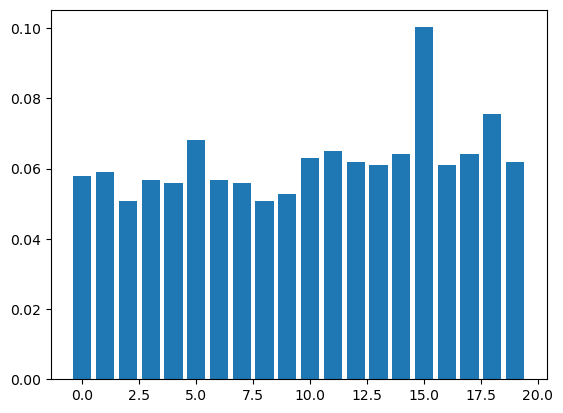

In [66]:
fig, ax = plt.subplots()
ax.bar(range(len(inds)), inds)

In [68]:
freq_df = pd.DataFrame({
    "number": range(len(inds)),
    "index of coincidence": inds
})

In [70]:
freq_df

,number,index of coincidence
0,0,0.057851
1,1,0.058884
2,2,0.050620
3,3,0.056818
4,4,0.055785
5,5,0.068182
6,6,0.056818
7,7,0.055785
8,8,0.050620
9,9,0.052686


In [72]:
alt.Chart(freq_df).mark_bar().encode(
    x="number:O",
    y="index of coincidence",
    tooltip=["index of coincidence"]
)

alt.Chart(...)

`lines[15]` has the highest index of coincidence, so let's see what happens when we try to shift it

In [74]:
c = lines[15]

In [76]:
c

'BPIWDCTHTKTCINIWGTTPHJBBTGHTHHXDCDCTJRXGKXCT\n'

In [78]:
shift_string(c, 0)

'BPIWDCTHTKTCINIWGTTPHJBBTGHTHHXDCDCTJRXGKXCT\n'

In [80]:
shift_string(c, 1)

'CQJXEDUIULUDJOJXHUUQIKCCUHIUIIYEDEDUKSYHLYDU\n'

In [82]:
shift_string(c, 5)

'GUNBIHYMYPYHNSNBLYYUMOGGYLMYMMCIHIHYOWCLPCHY\n'

Notice how "W" shifted by 5 gives us "B", "WXYZAB".  In terms of the number equivalents: "W" is 22, "B" is 1.  22 + 5 = 27, then we reduce modulo 26 to get 1.

In [84]:
c

'BPIWDCTHTKTCINIWGTTPHJBBTGHTHHXDCDCTJRXGKXCT\n'

In [86]:
c = "BPIWDCTHTKTCINIWGTTPHJBBTGHTHHXDCDCTJRXGKXCT"

How can we decrypt `c`?  In the Lab 0, you will try to automatically decrypt this kind of shift ciphertext.

To get some intuition for this process, try out this site: [Caesar cipher: Encode and deconde online - cryptii](https://cryptii.com/pipes/caesar-cipher/)

In [90]:
for i in range(26):
    print(f"Shift by {i}: {shift_string(c, i)}")

Shift by 0: BPIWDCTHTKTCINIWGTTPHJBBTGHTHHXDCDCTJRXGKXCT
Shift by 1: CQJXEDUIULUDJOJXHUUQIKCCUHIUIIYEDEDUKSYHLYDU
Shift by 2: DRKYFEVJVMVEKPKYIVVRJLDDVIJVJJZFEFEVLTZIMZEV
Shift by 3: ESLZGFWKWNWFLQLZJWWSKMEEWJKWKKAGFGFWMUAJNAFW
Shift by 4: FTMAHGXLXOXGMRMAKXXTLNFFXKLXLLBHGHGXNVBKOBGX
Shift by 5: GUNBIHYMYPYHNSNBLYYUMOGGYLMYMMCIHIHYOWCLPCHY
Shift by 6: HVOCJIZNZQZIOTOCMZZVNPHHZMNZNNDJIJIZPXDMQDIZ
Shift by 7: IWPDKJAOARAJPUPDNAAWOQIIANOAOOEKJKJAQYENREJA
Shift by 8: JXQELKBPBSBKQVQEOBBXPRJJBOPBPPFLKLKBRZFOSFKB
Shift by 9: KYRFMLCQCTCLRWRFPCCYQSKKCPQCQQGMLMLCSAGPTGLC
Shift by 10: LZSGNMDRDUDMSXSGQDDZRTLLDQRDRRHNMNMDTBHQUHMD
Shift by 11: MATHONESEVENTYTHREEASUMMERSESSIONONEUCIRVINE
Shift by 12: NBUIPOFTFWFOUZUISFFBTVNNFSTFTTJPOPOFVDJSWJOF
Shift by 13: OCVJQPGUGXGPVAVJTGGCUWOOGTUGUUKQPQPGWEKTXKPG
Shift by 14: PDWKRQHVHYHQWBWKUHHDVXPPHUVHVVLRQRQHXFLUYLQH
Shift by 15: QEXLSRIWIZIRXCXLVIIEWYQQIVWIWWMSRSRIYGMVZMRI
Shift by 16: RFYMTSJXJAJSYDYMWJJFXZRRJWXJXXNTSTSJZHNWANSJ
Shift by 17: SGZNUTKYKBK

We can now confirm line 16 (at index 15) had the shifted English text. You may already be able to see which shift value returns the plaintext (it's not 15 or 16). But how could we get an idea of which shift works best without visual inspection?

Let's try the index of coincidence.

In [92]:
for i in range(26):
    print(ind_co(get_freq(shift_string(c, i))))

0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024792
0.10020661157024792
0.10020661157024793
0.10020661157024793
0.10020661157024792
0.10020661157024792
0.1002066115702479
0.1002066115702479
0.1002066115702479
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793
0.10020661157024793


This won't help! These should be exactly the same, shifting the characters leads to summing up the same values in the calculation of `ind_co` (albeit in a different order).

Rather, we should use the mutual index of coincidence to compare the shifted text with actual English text.

In [96]:
pride_freq = get_freq(s)

In [98]:
pride_freq

{'a': 0.07739003458965348,
 'b': 0.016852962904150066,
 'c': 0.02560911620328498,
 'd': 0.04094835025994021,
 'e': 0.12850815722067646,
 'f': 0.022428041783749075,
 'g': 0.018998418955958603,
 'h': 0.06241671902292859,
 'i': 0.07110900918938698,
 'j': 0.0017501950414592553,
 'k': 0.006035929053237688,
 'l': 0.04052029466794623,
 'm': 0.02715909169365028,
 'n': 0.07022700754620584,
 'o': 0.07487693401730174,
 'p': 0.015803536291519666,
 'q': 0.001139180204500107,
 'r': 0.06070449665495267,
 's': 0.06161066272671412,
 't': 0.0878428759812484,
 'u': 0.028141203112378402,
 'v': 0.010561581320206296,
 'w': 0.022467740487845292,
 'x': 0.0017812635924910763,
 'y': 0.02344122175350902,
 'z': 0.0016759757251054604}

For every possible shift amount, from 0 to 25 (inclusive), we will shift the ciphertext c by that amount, and compute its Mutual Index of Coincidence with the Pride and Prejudice frequencies (representing "average" English).  Look for the value that is bigger than the rest.

In [100]:
for i in range(26):
    print(f"shift by {i} gives MutIndCo = {mut_ind_co(get_freq(shift_string(c,i)), pride_freq)}")

shift by 0 gives MutIndCo = 0.043246167741303784
shift by 1 gives MutIndCo = 0.04032215419918141
shift by 2 gives MutIndCo = 0.035914421205447224
shift by 3 gives MutIndCo = 0.034014924515973946
shift by 4 gives MutIndCo = 0.03205097627429702
shift by 5 gives MutIndCo = 0.03849248329359278
shift by 6 gives MutIndCo = 0.03497883415732988
shift by 7 gives MutIndCo = 0.051290882604184775
shift by 8 gives MutIndCo = 0.027283287441840613
shift by 9 gives MutIndCo = 0.02989516403881121
shift by 10 gives MutIndCo = 0.041080587741667826
shift by 11 gives MutIndCo = 0.07242973643198718
shift by 12 gives MutIndCo = 0.041651276227035156
shift by 13 gives MutIndCo = 0.0282089498139339
shift by 14 gives MutIndCo = 0.029701377874547075
shift by 15 gives MutIndCo = 0.04080673729374718
shift by 16 gives MutIndCo = 0.0338052902524461
shift by 17 gives MutIndCo = 0.038217181410838595
shift by 18 gives MutIndCo = 0.03505854538927011
shift by 19 gives MutIndCo = 0.027886260545262487
shift by 20 gives MutI

In [102]:
MutIndCo_arr = np.zeros(26)
for i in range(26):
    MutIndCo_arr[i] = mut_ind_co(get_freq(shift_string(c,i)), pride_freq)

MutIndCo_arr.max()

0.07242973643198718

In [104]:
plainshift = MutIndCo_arr.argmax() #argmax is where the max occurs!
print(plainshift)

11


In [106]:
shift_string(c, plainshift)

'MATHONESEVENTYTHREEASUMMERSESSIONONEUCIRVINE'